# Binning

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_csv("data/titanic.csv", usecols=['Age', 'Fare', 'Survived'])
df.sample(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [35]:
df.loc[df['Age'].isnull(), 'Age'] = df['Age'].dropna().sample(df['Age'].isnull().sum()).values

In [36]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [37]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

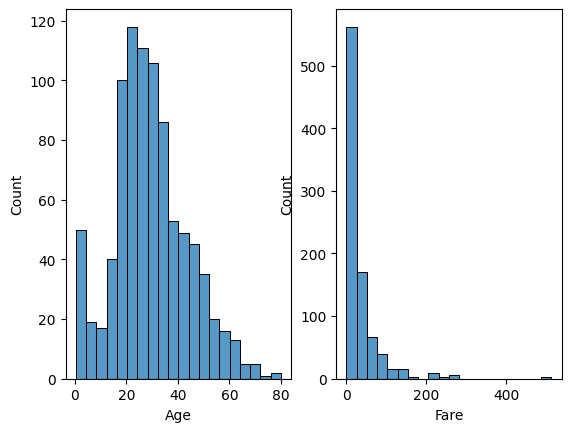

In [38]:
plt.subplot(121)
sns.histplot(df['Age'], bins=20)


plt.subplot(122)
sns.histplot(df['Fare'], bins = 20)
plt.show()


In [45]:
kbd_age = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
kbd_fare = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

trf = ColumnTransformer(transformers=[
    ('kbd_age', kbd_age, ['Age']),
    ('kbd_fare', kbd_fare, ['Fare'])
], verbose_feature_names_out=False, remainder='passthrough')

In [46]:
X_train_trfd = pd.DataFrame(trf.fit_transform(X_train),
                            index=X_train.index,
                            columns=trf.get_feature_names_out())
X_test_trfd = pd.DataFrame(trf.transform(X_test),
                            index=X_test.index,
                            columns=trf.get_feature_names_out())


C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warn

In [47]:
trf.transformers_[0][1].bin_edges_
trf.named_transformers_['kbd_fare'].bin_edges_

array([array([  0.     ,   7.88252,  12.13   ,  23.45   ,  46.9    , 512.3292 ])],
      dtype=object)

In [48]:
model = DecisionTreeClassifier()

cross_val_score(model, X_train, y_train, cv = 5).mean()

np.float64(0.6083483870967742)

In [49]:
cross_val_score(model, X_train_trfd, y_train, cv = 5).mean()

np.float64(0.6453032258064516)

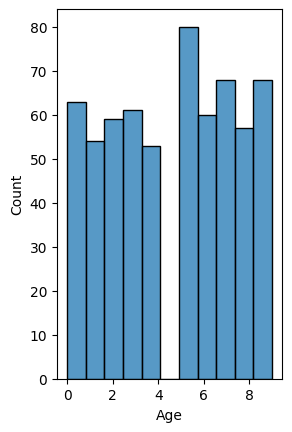

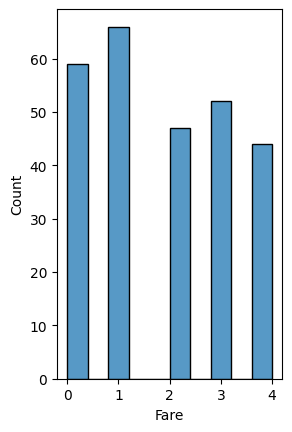

In [50]:
plt.subplot(121)
sns.histplot(X_train_trfd['Age'])
plt.show()

plt.subplot(122)
sns.histplot(X_test_trfd['Fare'])
plt.show()

# Binarization

In [53]:
from sklearn.preprocessing import Binarizer

Adult_binarizer = Binarizer(threshold=18)
senior_citizen_binarizer = Binarizer(threshold=60)

X_train['Adult'] = Adult_binarizer.fit_transform(X_train[['Age']]) 
X_test['Adult'] = Adult_binarizer.transform(X_test[['Age']]) 

X_train['senior_citizen'] = senior_citizen_binarizer.fit_transform(X_train[['Age']])
X_test['senior_citizen'] = senior_citizen_binarizer.transform(X_test[['Age']])

In [54]:
X_train.head()

,Age,Fare,Adult,senior_citizen
857,51.0,26.5500,1.0,0.0
52,49.0,76.7292,1.0,0.0
386,1.0,46.9000,0.0,0.0
124,54.0,77.2875,1.0,0.0
578,37.0,14.4583,1.0,0.0
